# Результаты

В ходе моделирования мной опробованы разные варианты размерности модели. Однако, предсказываемые маски для всех типов облаков больше выделяют сами облака чем конкретные.
Так же к этому добавляется общее непонимание какие конкретно облака относятся к предсказываемым типам. То есть визуально определить правильность предсказаний не удается.
Вполне возможно моя модель недообучена и поэтому она справляется с определением облаков в общем, но не частном порядке.

При увеличении количества эпох с 25 до 50 модель на некоторых типах облаков начала разряжаться в пространстве и предсказывать много, но неправильно.
Это вполне возможно из-за низкого порога представления изображения в черно-белом канале (отдельные малые белые облака начинают размывать картину, ибо такие облака появляются относительно везде возможно как в целом дефект изображения)

На графике ниже видно планомерное снижение ошибки на обучении, однако, метрика теста хоть и снижается, но сильно скачет. Изменения весов скорее всего происходит слишком сильно и метрику качает то в одну сторону, то в другую.

В целом суть построения сегментной маски понятна (за исключением ряда НО):
- Принципы подбора порога для создания сегментной маски.
- Сочетание выходов модели с функцией потерь.
- Подбор количества эпох обучения.

![img](train_plot.svg)



In [23]:
import mlflow
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from cnn_model import EncoderDecoder
from model_utils import transpose_image, get_image, get_image_rle, crop, get_gray_color_image, dice_loss
from plt_utils import show_image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data = pd.read_csv("dataset/understanding_cloud_organization/train.csv")

splitted = data['Image_Label'].str.split(pat='_', expand=True)

data['Image'] = splitted[0]
data['Label'] = splitted[1]

print(data[["Label", "EncodedPixels"]].groupby("Label").count())

criterion = nn.BCEWithLogitsLoss()

# model = EncoderDecoder().to(device)
# model.load_state_dict(torch.load("cnn_model.pt", weights_only=True))
model = mlflow.pytorch.load_model("runs:/ce3cef10b3fd4502bc5ec215d6445491/final_model")
model.eval()

crop_number = 11
image_name = data.iloc[1586]["Image"]
image_name = data.iloc[0]["Image"]
# image_windows, x_data, y_data = crop(get_edge(get_image(image_name=image_name), 150, 250))
image_windows, x_data, y_data = crop(get_gray_color_image(get_image(image_name=image_name), 150))
image = image_windows[crop_number]

test_X = torch.Tensor([transpose_image(image_window) for image_window in image_windows]).to(device)
result = model(test_X)

test_y = (torch.Tensor(
    [val for val in zip(*map(lambda x: crop(x)[0], get_image_rle(data, image_name)))])
          .to(device))
print(criterion(result, test_y))
# print(result)

        EncodedPixels
Label                
Fish             2781
Flower           2365
Gravel           2939
Sugar            3751


tensor(0.5459, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


In [24]:
logits_stats = {
    'min': result.min().item(),
    'max': result.max().item(),
    'mean': result.mean().item(),
    'std': result.std().item()
}
print(f"Logits stats: {logits_stats}")
after_sigmoid = torch.sigmoid(result)
logits_stats = {
    'min': after_sigmoid.min().item(),
    'max': after_sigmoid.max().item(),
    'mean': after_sigmoid.mean().item(),
    'std': after_sigmoid.std().item()
}
print(f"Logits stats: {logits_stats}")

Logits stats: {'min': -5.997142791748047, 'max': 1.787907361984253, 'mean': -1.7013887166976929, 'std': 0.5703345537185669}
Logits stats: {'min': 0.0024796805810183287, 'max': 0.8566705584526062, 'mean': 0.1683448851108551, 'std': 0.07657148689031601}


    Label                                      EncodedPixels
0    Fish  264918 937 266318 937 267718 937 269118 937 27...
1  Flower  1355565 1002 1356965 1002 1358365 1002 1359765...
2  Gravel                                                NaN
3   Sugar                                                NaN
Dice Loss при пороге 0.15744692087173462: 0.8336383104324341


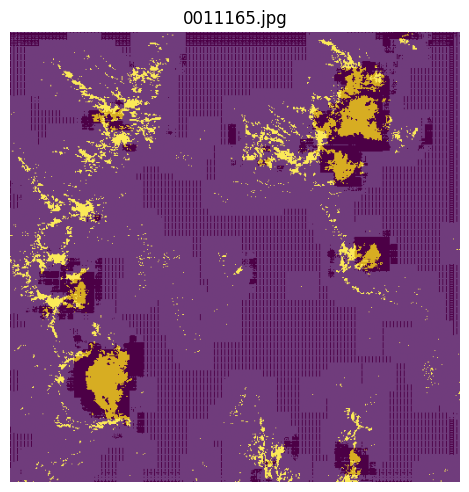

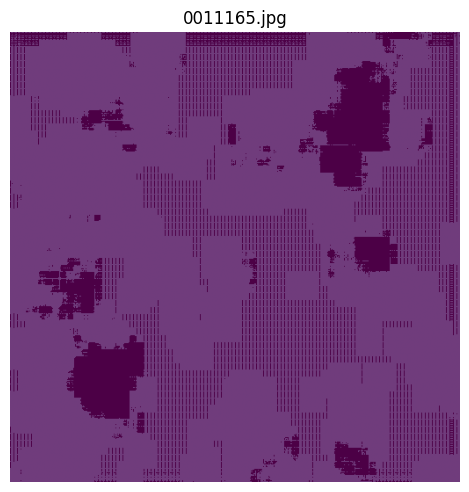

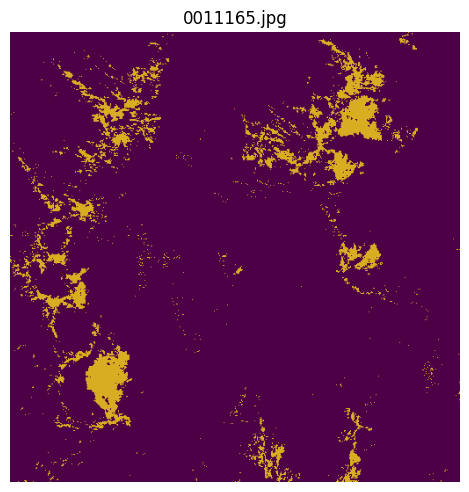

In [25]:
print(data[data['Image'] == image_name][["Label", "EncodedPixels"]])
element = 3
# превращение в маску
threshold = after_sigmoid.median()
result_mask = after_sigmoid >= threshold
after_sigmoid[result_mask] = 1
result_mask = after_sigmoid < threshold
after_sigmoid[result_mask] = 0

dice_loss = dice_loss(test_y, after_sigmoid)
print(f"Dice Loss при пороге {threshold}: {dice_loss}")

show_image(image, after_sigmoid[crop_number][element].to('cpu').detach().numpy(), image_name)
show_image(np.zeros((1400, 2100)), after_sigmoid[crop_number][element].to('cpu').detach().numpy(), image_name)
show_image(image,
           [val for val in zip(*map(lambda x: crop(x)[0], get_image_rle(data, image_name)))][crop_number][element],
           title=f"{image_name}")